In [1]:
%load_ext autoreload
%autoreload 2

import torch
import torch.nn as nn
import numpy as np

from torch.utils.data import TensorDataset, DataLoader
from torch.nn.utils import parameters_to_vector, vector_to_parameters
from tqdm import tqdm
from collections import defaultdict
import matplotlib.pyplot as plt
from sv3.nn import FunctionalModelJac, MLP
from sv3.svd_sgd import SVDOptimizer
import sys
sys.path.append('..')
import copy

import json

device = torch.device('cuda' if torch.cuda.is_available() else ('mps' if torch.backends.mps.is_available() else 'cpu'))
print(f"Using device: {device}")

Using device: cuda


In [7]:
from torchvision import datasets, transforms
from experiments.datasets.all_datasets import RandomPolynomialDataset


num_inputs = 6
SEED = 9056829
random_poly = RandomPolynomialDataset(degree=4, num_vars=num_inputs, seed=57728)
train_dataset = random_poly.train_dataset
test_dataset = random_poly.val_dataset

In [10]:
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

input_dim = num_inputs
hidden_layers = [16,16,16]
output_size = 1

num_epochs = 10

mlp_init = MLP(input_dim, hidden_layers, output_size)
mlp_params = copy.deepcopy(mlp_init.state_dict())
del mlp_init

# Adam

In [4]:
model_sup = MLP(input_dim, hidden_layers, output_size)
model_sup.load_state_dict(mlp_params)
model_sup.to(device)
optimizer = torch.optim.Adam(model_sup.parameters(), lr=1e-3)
loss_fn = nn.MSELoss()

losses_direct = defaultdict(list)

# save untrained validation loss
val_init = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        ypred = model_sup(xb)
        loss = loss_fn(ypred, yb)
        val_init.append(loss.item())
losses_direct['val'].append(np.mean(val_init))

for epoch in tqdm(range(num_epochs)):
    epoch_losses = defaultdict(list)
    model_sup.train()
    for xb, yb in train_loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        ypred = model_sup(xb)
        loss = loss_fn(ypred, yb)
        loss.backward()
        optimizer.step()
        epoch_losses['train'].append(loss.item())
    model_sup.eval()
    with torch.no_grad():
        for xb, yb in test_loader:
            xb, yb = xb.to(device), yb.to(device)
            ypred = model_sup(xb)
            loss = loss_fn(ypred, yb)
            epoch_losses['val'].append(loss.item())
    # Save batch-wise losses
    losses_direct['train_batch'].extend(epoch_losses['train'])
    losses_direct['val_batch'].extend(epoch_losses['val'])
    # Save epoch-averaged losses
    for k,v in epoch_losses.items():
        losses_direct[k].append(np.mean(v))
#with open("mnist_direct_losses.pt", "w") as f:
#    json.dump(losses_direct, f)

  5%|▌         | 10/200 [00:14<04:29,  1.42s/it]


KeyboardInterrupt: 

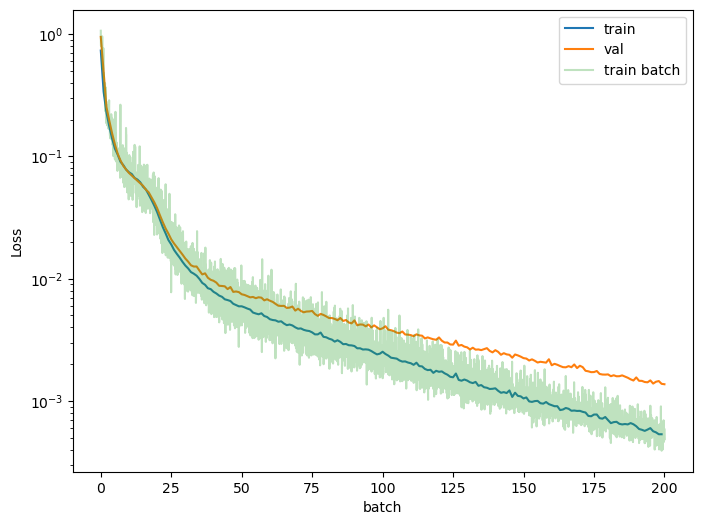

In [5]:
#with open("mnist_direct_losses.pt", "r") as f:
#    losses_direct = json.load(f)
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='train')
plt.plot(losses_direct['val'], label='val')
xvals = np.linspace(0,num_epochs,len(losses_direct['train_batch']))
plt.plot(xvals, losses_direct['train_batch'], label='train batch', alpha=0.3)
#plt.plot(losses_direct['val_batch'], label='val')
plt.xlabel('batch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# SVD

In [11]:
mlp_svd = MLP(input_dim=input_dim,hidden_dims=hidden_layers,output_dim=output_size)
mlp_svd.load_state_dict(mlp_params)
mlp_svd.to(device)
loss_fn = nn.MSELoss(reduction='none')
loss_lambda = lambda pred, y: loss_fn(pred, y).squeeze()

lr_svd = 0.1
k_svd = batch_size
rtol = 1e-3 
model_svd = FunctionalModelJac(mlp_svd, loss_lambda, device)
opt_svd = SVDOptimizer(model_svd, lr=lr_svd, k=k_svd, rtol=rtol, track_svd_info=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, drop_last=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, drop_last=True)

losses_svd = defaultdict(list)

# save untrained validation loss
val_init = []
with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        ypred = model_svd.evaluate(xb)
        loss = loss_lambda(ypred, yb).mean()
        val_init.append(loss.item())
losses_svd['val'].append(np.mean(val_init))

# Ensure all computations are done without gradients
with torch.no_grad():
    for epoch in tqdm(range(num_epochs)):
        epoch_losses = defaultdict(list)
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            batch = (xb, yb)
            losses,preds = model_svd.loss_and_grad(batch)
            opt_svd.step()
            epoch_losses['train'].append(losses.mean().item())
        
        for xb, yb in test_loader:
            xb, yb = xb.to(device).detach(), yb.to(device).detach()
            ypred = model_svd.evaluate(xb)
            loss = loss_lambda(ypred, yb).mean()
            epoch_losses['val'].append(loss.item())
        
        # Save batch-wise losses
        losses_svd['train_batch'].extend(epoch_losses['train'])
        losses_svd['val_batch'].extend(epoch_losses['val'])
        # Save epoch-averaged losses
        for k_name, v in epoch_losses.items():
            losses_svd[k_name].append(np.mean(v))
torch.compiler.reset()

  0%|          | 0/10 [00:00<?, ?it/s]/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/jax/lib/python3.12/site-packages/torch/_inductor/lowering.py:1725: FutureWarning: `torch._prims_common.check` is deprecated and will be removed in the future. Please use `torch._check*` functions instead.
  check(


tensor([1.2122e+01, 2.5314e+00, 1.1738e+00, 9.7570e-01, 7.4970e-01, 5.5576e-01,
        4.3680e-01, 3.4176e-01, 2.9261e-01, 2.2178e-01, 1.3514e-01, 1.1161e-01,
        8.6394e-02, 7.0874e-02, 6.3567e-02, 5.2041e-02, 4.6212e-02, 4.0040e-02,
        3.5509e-02, 3.3691e-02, 2.7765e-02, 2.5858e-02, 2.1473e-02, 1.6730e-02,
        1.2231e-02, 1.1744e-02, 1.0906e-02, 8.5891e-03, 7.5135e-03, 5.8826e-03,
        1.0661e-03, 3.3914e-04], device='cuda:0')
tensor([1.0912e+01, 4.0007e+00, 3.1726e+00, 2.3406e+00, 1.6682e+00, 1.3893e+00,
        1.1745e+00, 8.9548e-01, 8.4276e-01, 7.6640e-01, 5.4202e-01, 5.0642e-01,
        4.3171e-01, 3.6612e-01, 2.7394e-01, 2.4344e-01, 2.2949e-01, 1.9820e-01,
        1.7362e-01, 1.3841e-01, 1.1682e-01, 1.0187e-01, 5.7437e-02, 4.8659e-02,
        4.8412e-02, 4.5773e-02, 3.4517e-02, 3.1869e-02, 1.4661e-02, 1.1799e-02,
        4.6439e-03, 9.8313e-04], device='cuda:0')
tensor([1.2059e+01, 6.0665e+00, 5.0072e+00, 4.0726e+00, 2.7184e+00, 2.1879e+00,
        1.4579e+00, 

  0%|          | 0/10 [00:12<?, ?it/s]

tensor([9.0388e+00, 4.4072e+00, 2.9368e+00, 2.1289e+00, 1.9179e+00, 1.5844e+00,
        1.4733e+00, 1.1535e+00, 1.0215e+00, 9.0352e-01, 7.4642e-01, 5.7388e-01,
        5.5444e-01, 4.5952e-01, 3.5613e-01, 3.0965e-01, 2.7135e-01, 2.4372e-01,
        1.9733e-01, 1.5211e-01, 9.5886e-02, 8.3749e-02, 5.5262e-02, 3.6861e-02,
        3.0181e-02, 2.5544e-02, 1.8366e-02, 1.5410e-02, 8.8478e-03, 6.6756e-03,
        4.0837e-03, 1.8606e-03], device='cuda:0')
tensor([4.5999e+01, 9.9590e+00, 5.8609e+00, 4.8076e+00, 2.5378e+00, 2.2753e+00,
        1.2339e+00, 1.0552e+00, 8.8003e-01, 7.3016e-01, 5.6334e-01, 3.7355e-01,
        3.3952e-01, 2.9343e-01, 2.7082e-01, 2.4146e-01, 1.8438e-01, 1.4847e-01,
        1.1636e-01, 7.1372e-02, 6.3586e-02, 5.5054e-02, 4.4464e-02, 2.7919e-02,
        2.3003e-02, 1.7647e-02, 1.4326e-02, 1.0895e-02, 7.6537e-03, 2.1665e-03,
        1.7464e-03, 5.9123e-04], device='cuda:0')
tensor([1.5500e+01, 3.0887e+00, 2.1478e+00, 1.8326e+00, 1.6753e+00, 1.1787e+00,
        1.0393e+00, 

KeyboardInterrupt: 

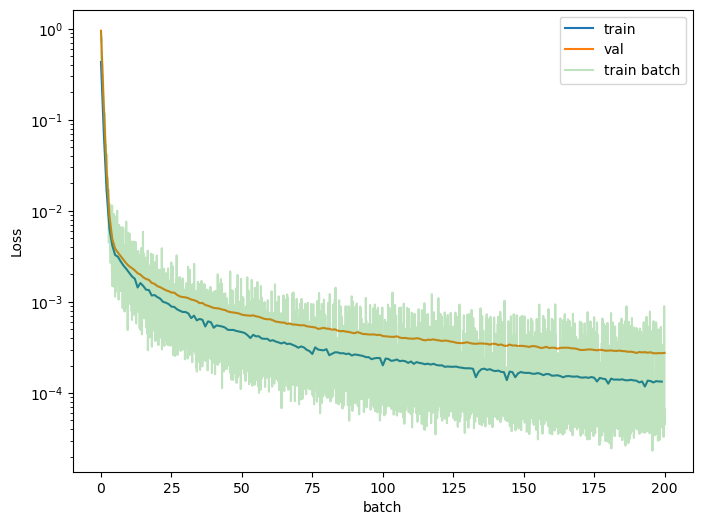

In [7]:
plt.figure(figsize=(8,6))
plt.plot(losses_svd['train'], label='train')
plt.plot(losses_svd['val'], label='val')
xvals = np.linspace(0,num_epochs,len(losses_svd['train_batch']))
plt.plot(xvals, losses_svd['train_batch'], label='train batch', alpha=0.3)
plt.xlabel('batch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

# comparison

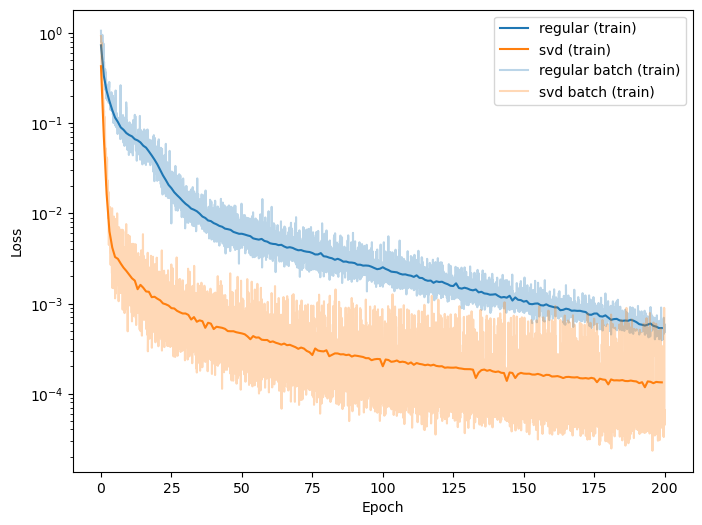

In [10]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['train'], label='regular (train)',color="C0")
plt.plot(losses_svd['train'], label='svd (train)',color="C1")
xvals = np.linspace(0,num_epochs,len(losses_direct['train_batch']))
xvals_svd = np.linspace(0,num_epochs,len(losses_svd['train_batch']))    
plt.plot(xvals, losses_direct['train_batch'], label='regular batch (train)', alpha=0.3)
plt.plot(xvals_svd, losses_svd['train_batch'], label='svd batch (train)', alpha=0.3)
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()

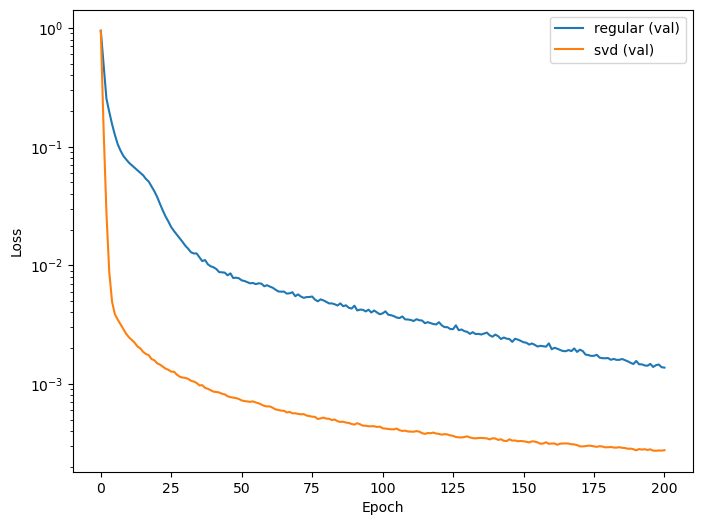

In [11]:
plt.figure(figsize=(8,6))
plt.plot(losses_direct['val'], label='regular (val)',color="C0")
plt.plot(losses_svd['val'], label='svd (val)',color="C1")
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.yscale('log')
plt.legend()
plt.show()